# IEEE-CIS Fraud Detection — Cost-Optimized Two-Stage Cascade

## LightGBM Stage 1 → XGBoost + CatBoost Stage 2

This notebook keeps the existing feature-engineering and three base-model training pipeline, but the final decision architecture is a **cascade** rather than a generic stack.


## 0. Configuration

The only cell you normally touch. `PRESET` trades runtime for score.

In [1]:
# ---------------------------------------------------------------- configuration
PRESET = "fast"          # "debug" | "fast" | "full"
SEED = 42
FOLD_STRATEGY = "group_month"   # "group_month" (time-aware) | "stratified"
MODELS = ["lgb", "xgb", "cat"]  # drop any to skip that base model
REDUCE_V = True                 # collapse the 339 V* columns to a low-correlation subset
USE_GPU = True                  # auto-downgrades to CPU when no GPU is present
START_DATE = "2017-11-30"       # community reference date for TransactionDT

_PRESETS = {
    # n_folds, lr,   lgb_rounds, xgb_rounds, cat_rounds, early_stop, rows,  eta
    "debug": dict(n_folds=2, lr=0.20, lgb=60,   xgb=60,   cat=80,   early_stop=20,  rows=6000, eta="~3 min"),
    "fast":  dict(n_folds=3, lr=0.08, lgb=1500, xgb=1500, cat=2500, early_stop=150, rows=None, eta="~1-1.5 h"),
    "full":  dict(n_folds=5, lr=0.03, lgb=4000, xgb=4000, cat=6000, early_stop=200, rows=None, eta="~3-5 h"),
    "max":   dict(n_folds=6, lr=0.015, lgb=9000, xgb=9000, cat=12000, early_stop=400, rows=None, eta="8 h+, may not finish"),
}
assert PRESET in _PRESETS, f"PRESET must be one of {list(_PRESETS)}"
CFG = _PRESETS[PRESET]

N_FOLDS = CFG["n_folds"]
LEARNING_RATE = CFG["lr"]
LGB_ROUNDS, XGB_ROUNDS, CAT_ROUNDS = CFG["lgb"], CFG["xgb"], CFG["cat"]
EARLY_STOP = CFG["early_stop"]
DEBUG_ROWS = CFG["rows"]        # None -> use every row

print(f"preset={PRESET}  folds={N_FOLDS}  lr={LEARNING_RATE}  early_stop={EARLY_STOP}")
print(f"rounds: lgb={LGB_ROUNDS} xgb={XGB_ROUNDS} cat={CAT_ROUNDS}")
print(f"rows={'all' if DEBUG_ROWS is None else DEBUG_ROWS}  models={MODELS}")
print(f"expected runtime on a Kaggle GPU session: {CFG['eta']}")
if PRESET == "max":
    print("WARNING: 'max' can exceed the 9 h session limit. Drop 'cat' or 'lgb' from MODELS,\n"
          "         or run 'full' instead. LightGBM is CPU-bound on Kaggle and dominates the cost.")

preset=fast  folds=3  lr=0.08  early_stop=150
rounds: lgb=1500 xgb=1500 cat=2500
rows=all  models=['lgb', 'xgb', 'cat']
expected runtime on a Kaggle GPU session: ~1-1.5 h


## 1. Environment, imports and GPU detection

Version-tolerant: XGBoost 1.x and 2.x/3.x use different GPU switches, and the
LightGBM wheel on Kaggle is usually CPU-only, so GPU support is probed rather than assumed.

In [2]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install xgboost 

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gc
import json
import os
import random
import subprocess
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 200)

IN_NOTEBOOK = "ipykernel" in sys.modules
import matplotlib
if not IN_NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from scipy.optimize import minimize
from scipy.special import expit, logit
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, precision_recall_curve,
)
from sklearn.model_selection import GroupKFold, StratifiedKFold


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


seed_everything(SEED)


def has_gpu() -> bool:
    """True when a usable NVIDIA device is visible."""
    try:
        return subprocess.run(
            ["nvidia-smi"], capture_output=True, timeout=60
        ).returncode == 0
    except Exception:
        return False


GPU = bool(USE_GPU and has_gpu())

XGB_MAJOR = int(xgb.__version__.split(".")[0])
if GPU and XGB_MAJOR >= 2:
    XGB_DEVICE = {"device": "cuda", "tree_method": "hist"}
elif GPU:
    XGB_DEVICE = {"tree_method": "gpu_hist", "predictor": "gpu_predictor"}
else:
    XGB_DEVICE = {"tree_method": "hist"}


def lgb_device() -> dict:
    """Most LightGBM wheels are CPU-only; probe a 1-round fit before committing."""
    if not GPU:
        return {}
    probe = lgb.Dataset(np.random.rand(64, 4), label=np.random.randint(0, 2, 64))
    for dev in ("cuda", "gpu"):
        try:
            lgb.train(
                {"objective": "binary", "device_type": dev, "verbose": -1, "num_leaves": 3},
                probe,
                num_boost_round=1,
            )
            return {"device_type": dev}
        except Exception:
            continue
    return {}


LGB_DEVICE = lgb_device()
CAT_DEVICE = {"task_type": "GPU", "devices": "0"} if GPU else {"task_type": "CPU"}

# ------------------------------------------------------------------------ paths
# Local Windows project folder used for this run.
LOCAL_DATA_DIR = Path(r"C:\Users\madhu\OneDrive\Desktop\cts")
KAGGLE_INPUT = Path("/kaggle/input/ieee-fraud-detection")

if KAGGLE_INPUT.exists():
    DATA_DIR = KAGGLE_INPUT
else:
    DATA_DIR = LOCAL_DATA_DIR

OUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else DATA_DIR / "cascade_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

REQUIRED_FILES = [
    "train_transaction.csv", "test_transaction.csv",
    "train_identity.csv", "test_identity.csv",
]
missing = [f for f in REQUIRED_FILES if not (DATA_DIR / f).exists()]
print(f"local data dir: {LOCAL_DATA_DIR}")
print(f"selected data dir: {DATA_DIR.resolve()}")
if missing:
    raise FileNotFoundError(
        "Missing required IEEE-CIS raw files in DATA_DIR: " + ", ".join(missing) +
        "\nSet LOCAL_DATA_DIR to the folder containing train_transaction.csv, "
        "test_transaction.csv, train_identity.csv and test_identity.csv."
    )

print(f"python      {sys.version.split()[0]}")
print(f"pandas      {pd.__version__}")
print(f"numpy       {np.__version__}")
print(f"lightgbm    {lgb.__version__}   -> {LGB_DEVICE or {'device_type': 'cpu'}}")
print(f"xgboost     {xgb.__version__}   -> {XGB_DEVICE}")
print(f"catboost    -> {CAT_DEVICE}")
print(f"gpu         {GPU}")
print(f"data dir    {DATA_DIR.resolve()}")
print(f"output dir  {OUT_DIR.resolve()}")
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"{DATA_DIR} not found. On Kaggle add the 'ieee-fraud-detection' competition data; "
        "locally set IEEE_DATA_DIR to the folder holding train_transaction.csv."
    )

local data dir: C:\Users\madhu\OneDrive\Desktop\cts
selected data dir: C:\Users\madhu\OneDrive\Desktop\cts
python      3.14.6
pandas      3.0.5
numpy       2.5.2
lightgbm    4.7.0   -> {'device_type': 'cpu'}
xgboost     3.4.1   -> {'tree_method': 'hist'}
catboost    -> {'task_type': 'CPU'}
gpu         False
data dir    C:\Users\madhu\OneDrive\Desktop\cts
output dir  C:\Users\madhu\OneDrive\Desktop\cts\cascade_outputs


## 1b. Small helpers

`reduce_mem_usage` matters here: the merged frame is ~1.1 M rows × 430+ columns,
and float64 → float32 roughly halves it.

In [3]:
class Timer:
    """Context manager that prints wall time for a labelled block."""

    def __init__(self, label: str):
        self.label = label

    def __enter__(self):
        self.t0 = time.time()
        print(f"[{self.label}] start")
        return self

    def __exit__(self, *exc):
        print(f"[{self.label}] done in {time.time() - self.t0:.1f}s")
        return False


def non_numeric_cols(df: pd.DataFrame) -> list:
    """Version-safe replacement for select_dtypes('object').

    pandas 3.0 reads text as StringDtype rather than object, so dtype-name checks break.
    """
    return [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]


def reduce_mem_usage(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    """Downcast numeric columns to the narrowest dtype that holds their range."""
    start = df.memory_usage(deep=True).sum() / 1024 ** 2
    for col in df.columns:
        s = df[col]
        if not pd.api.types.is_numeric_dtype(s) or pd.api.types.is_bool_dtype(s):
            continue
        cmin, cmax = s.min(), s.max()
        if pd.isna(cmin) or pd.isna(cmax):
            df[col] = s.astype(np.float32)
            continue
        if pd.api.types.is_integer_dtype(s):
            for dt in (np.int8, np.int16, np.int32, np.int64):
                if cmin >= np.iinfo(dt).min and cmax <= np.iinfo(dt).max:
                    df[col] = s.astype(dt)
                    break
        else:
            df[col] = s.astype(np.float32)
    end = df.memory_usage(deep=True).sum() / 1024 ** 2
    if verbose:
        print(f"  memory {start:.1f} MB -> {end:.1f} MB ({100 * (start - end) / max(start, 1e-9):.1f}% saved)")
    return df


def sanitize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """LightGBM/XGBoost reject '[', ']', '<' and friends in feature names."""
    clean, seen = [], {}
    for c in df.columns:
        c2 = "".join(ch if (ch.isalnum() or ch == "_") else "_" for ch in str(c))
        if c2 in seen:
            seen[c2] += 1
            c2 = f"{c2}_{seen[c2]}"
        else:
            seen[c2] = 0
        clean.append(c2)
    df.columns = clean
    return df

## 2. Load and merge the data

Four files: `{train,test}_transaction.csv` (the labelled core) and `{train,test}_identity.csv`
(device/network attributes, present for only ~24% of transactions). Identity is a left join,
so missingness itself carries signal and is deliberately left as NaN.

In [4]:
with Timer("load"):
    train_tx = pd.read_csv(DATA_DIR / "train_transaction.csv", nrows=DEBUG_ROWS)
    test_tx = pd.read_csv(DATA_DIR / "test_transaction.csv", nrows=DEBUG_ROWS)
    train_id = pd.read_csv(DATA_DIR / "train_identity.csv")
    test_id = pd.read_csv(DATA_DIR / "test_identity.csv")

    print(f"  train_transaction {train_tx.shape}   train_identity {train_id.shape}")
    print(f"  test_transaction  {test_tx.shape}   test_identity  {test_id.shape}")

    train = train_tx.merge(train_id, on="TransactionID", how="left")
    test = test_tx.merge(test_id, on="TransactionID", how="left")
    del train_tx, test_tx, train_id, test_id
    gc.collect()

    # Test files use id-01..id-38 (hyphen); train uses id_01..id_38 (underscore).
    test = test.rename(columns={c: c.replace("-", "_") for c in test.columns})

    print(f"  train {train.shape}   test {test.shape}")
    train = reduce_mem_usage(train)
    test = reduce_mem_usage(test)

[load] start
  train_transaction (590540, 394)   train_identity (144233, 41)
  test_transaction  (506691, 393)   test_identity  (141907, 41)
  train (590540, 434)   test (506691, 433)
  memory 1984.2 MB -> 1073.5 MB (45.9% saved)
  memory 1700.3 MB -> 922.3 MB (45.8% saved)
[load] done in 92.7s


In [5]:
# Quick orientation: class balance and the disjoint time ranges of train vs test.
y = train["isFraud"].astype(np.int8).to_numpy()
test_ids = test["TransactionID"].to_numpy()

print(f"rows            train={len(train):,}  test={len(test):,}")
print(f"fraud rate      {y.mean():.4%}  ({y.sum():,} positives)")
print(f"TransactionDT   train [{train.TransactionDT.min():,} .. {train.TransactionDT.max():,}]")
print(f"                test  [{test.TransactionDT.min():,} .. {test.TransactionDT.max():,}]")
print(f"gap between them {(test.TransactionDT.min() - train.TransactionDT.max()) / 86400:.1f} days")
print(f"\nidentity coverage  train={train.id_31.notna().mean():.1%}  test={test.id_31.notna().mean():.1%}")

missing = train.isna().mean().sort_values(ascending=False)
print(f"\ncolumns >90% missing: {(missing > 0.90).sum()} of {train.shape[1]}")
print(missing.head(8).round(4).to_string())

rows            train=590,540  test=506,691
fraud rate      3.4990%  (20,663 positives)
TransactionDT   train [86,400 .. 15,811,131]
                test  [18,403,224 .. 34,214,345]
gap between them 30.0 days

identity coverage  train=23.8%  test=27.0%

columns >90% missing: 12 of 434
id_24    0.9920
id_25    0.9913
id_07    0.9913
id_08    0.9913
id_21    0.9913
id_26    0.9913
id_27    0.9912
id_23    0.9912


## 3. Feature engineering

Train and test are concatenated so every encoder (frequency counts, group aggregates) sees a
single consistent vocabulary. No target-derived encoding is used anywhere, so this cannot leak
labels — the only thing shared across the split is the feature distribution.

In [6]:
n_train = len(train)
df = pd.concat([train.drop(columns=["isFraud"]), test], axis=0, ignore_index=True, sort=False)
del train, test
gc.collect()
print(f"combined frame {df.shape}")

V_COLS = [c for c in df.columns if c.startswith("V") and c[1:].isdigit()]
C_COLS = [f"C{i}" for i in range(1, 15) if f"C{i}" in df.columns]
D_COLS = [f"D{i}" for i in range(1, 16) if f"D{i}" in df.columns]
M_COLS = [f"M{i}" for i in range(1, 10) if f"M{i}" in df.columns]
ID_COLS = [c for c in df.columns if c.startswith("id_")]
print(f"V={len(V_COLS)}  C={len(C_COLS)}  D={len(D_COLS)}  M={len(M_COLS)}  id={len(ID_COLS)}")

combined frame (1097231, 433)
V=339  C=14  D=15  M=9  id=38


### 3.1 Collapse the V block

The 339 `V*` columns are heavily redundant. They fall into blocks that share an identical
missing-value pattern, and inside a block many columns are near-duplicates. Keep one
representative per correlated cluster — the one with the most distinct values, since it carries
the finest granularity. Typically ~130 of 339 survive, which cuts training time a lot for
almost no loss in AUC.

In [7]:
def pick_v_columns(frame: pd.DataFrame, v_cols: list, sample: int = 100_000,
                   corr_thr: float = 0.75) -> list:
    d = frame[v_cols].iloc[:sample]
    nan_groups: dict = {}
    for c in v_cols:
        nan_groups.setdefault(int(d[c].isna().sum()), []).append(c)

    keep = []
    for _, cols in nan_groups.items():
        if len(cols) == 1:
            keep.append(cols[0])
            continue
        sub = d[cols]
        try:
            corr = sub.corr()
        except Exception:
            keep.extend(cols)
            continue
        nunq = {c: sub[c].nunique() for c in cols}
        used = set()
        for c in cols:
            if c in used:
                continue
            cluster = [c] + [
                o for o in cols
                if o != c and o not in used and abs(corr.loc[c, o]) >= corr_thr
            ]
            keep.append(max(cluster, key=lambda x: nunq[x]))
            used.update(cluster)
    order = {c: i for i, c in enumerate(v_cols)}
    return sorted(set(keep), key=lambda c: order[c])


if REDUCE_V and V_COLS:
    with Timer("V reduction"):
        v_keep = pick_v_columns(df.iloc[:n_train], V_COLS)
        v_drop = [c for c in V_COLS if c not in v_keep]
        df = df.drop(columns=v_drop)
        print(f"  kept {len(v_keep)}/{len(V_COLS)} V columns, dropped {len(v_drop)}")
        V_COLS = v_keep
        gc.collect()

[V reduction] start
  kept 134/339 V columns, dropped 205
[V reduction] done in 9.9s


### 3.2 Time features

`TransactionDT` is seconds from an arbitrary origin. Absolute time must never become a feature
(test lies strictly in the future of train, so the model would extrapolate off a cliff), but
*cyclical* position within a day or week is legitimate and predictive — fraud clusters at night.
`DT_M` (calendar month) is built for grouping folds only and is dropped before training.

In [8]:
with Timer("time features"):
    day_float = df["TransactionDT"] / 86_400.0
    df["_day"] = np.floor(day_float).astype(np.int32)          # helper, dropped later
    df["hour"] = ((df["TransactionDT"] // 3600) % 24).astype(np.int8)
    df["dow"] = (df["_day"] % 7).astype(np.int8)
    df["dom"] = (df["_day"] % 30).astype(np.int8)
    df["is_night"] = df["hour"].isin([0, 1, 2, 3, 4, 5, 6, 7]).astype(np.int8)

    _dt = pd.to_datetime(START_DATE) + pd.to_timedelta(df["TransactionDT"], unit="s")
    df["DT_M"] = ((_dt.dt.year - 2017) * 12 + _dt.dt.month).astype(np.int16)   # fold groups only
    del _dt
    gc.collect()
    print(f"  month buckets: {sorted(df['DT_M'].unique().tolist())}")

[time features] start
  month buckets: [12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24]
[time features] done in 0.7s


### 3.3 Transaction amount

The fractional part of the amount is a surprisingly strong signal: foreign-currency conversions
produce long decimals, while human-entered or round amounts do not.

In [9]:
with Timer("amount features"):
    df["amt_log"] = np.log1p(df["TransactionAmt"]).astype(np.float32)
    df["amt_cents"] = (df["TransactionAmt"] - np.floor(df["TransactionAmt"])).round(4).astype(np.float32)
    df["amt_is_round"] = (df["amt_cents"] == 0).astype(np.int8)
    df["amt_decimal_len"] = (
        df["TransactionAmt"].astype(str).str.split(".").str[1].fillna("").str.len().astype(np.int8)
    )

[amount features] start
[amount features] done in 5.7s


### 3.4 Email domains

Raw domains are high-cardinality and inconsistent (`gmail` vs `gmail.com`, dozens of Yahoo
regional variants). Mapping to provider, then to suffix/country, produces columns that
generalise to domains only seen in test.

In [10]:
EMAIL_MAP = {
    "gmail": "google", "googlemail": "google", "att.net": "att", "twc.com": "spectrum",
    "scranton.edu": "other", "optonline.net": "other", "hotmail.co.uk": "microsoft",
    "comcast.net": "other", "yahoo.com.mx": "yahoo", "yahoo.fr": "yahoo", "yahoo.es": "yahoo",
    "charter.net": "spectrum", "live.com": "microsoft", "aim.com": "aol",
    "hotmail.de": "microsoft", "centurylink.net": "centurylink", "gmail.com": "google",
    "me.com": "apple", "earthlink.net": "other", "gmx.de": "other", "web.de": "other",
    "cfl.rr.com": "other", "hotmail.com": "microsoft", "protonmail.com": "other",
    "hotmail.fr": "microsoft", "windstream.net": "other", "outlook.es": "microsoft",
    "yahoo.co.jp": "yahoo", "yahoo.de": "yahoo", "servicios-ta.com": "other",
    "netzero.net": "other", "suddenlink.net": "other", "roadrunner.com": "other",
    "sc.rr.com": "other", "live.fr": "microsoft", "verizon.net": "yahoo",
    "msn.com": "microsoft", "q.com": "centurylink", "prodigy.net.mx": "att",
    "frontier.com": "yahoo", "anonymous.com": "other", "rocketmail.com": "yahoo",
    "sbcglobal.net": "att", "frontiernet.net": "yahoo", "ymail.com": "yahoo",
    "outlook.com": "microsoft", "mail.com": "other", "bellsouth.net": "other",
    "embarqmail.com": "centurylink", "cableone.net": "other", "hotmail.es": "microsoft",
    "mac.com": "apple", "yahoo.co.uk": "yahoo", "netzero.com": "other", "yahoo.com": "yahoo",
    "live.com.mx": "microsoft", "ptd.net": "other", "cox.net": "other", "aol.com": "aol",
    "juno.com": "other", "icloud.com": "apple",
}
US_SUFFIXES = {"com", "net", "edu", "gov", "us", "org"}

with Timer("email features"):
    for col in ["P_emaildomain", "R_emaildomain"]:
        if col not in df.columns:
            continue
        tag = col[0].lower()  # p / r
        low = df[col].astype(str).str.lower()
        df[f"{tag}_email_provider"] = low.map(EMAIL_MAP).fillna("other")
        df[f"{tag}_email_suffix"] = low.str.split(".").str[-1]
        df[f"{tag}_email_is_us"] = df[f"{tag}_email_suffix"].isin(US_SUFFIXES).astype(np.int8)
        df[f"{tag}_email_nparts"] = low.str.count(r"\.").fillna(0).astype(np.int8)
        df[f"{tag}_email_isna"] = df[col].isna().astype(np.int8)

    if {"P_emaildomain", "R_emaildomain"}.issubset(df.columns):
        df["email_match"] = (df["P_emaildomain"] == df["R_emaildomain"]).astype(np.int8)
        df["email_provider_match"] = (
            df["p_email_provider"] == df["r_email_provider"]
        ).astype(np.int8)
        df["email_both_present"] = (
            df["P_emaildomain"].notna() & df["R_emaildomain"].notna()
        ).astype(np.int8)

[email features] start
[email features] done in 6.0s


### 3.5 Device, browser, OS and screen resolution

`id_30`/`id_31`/`id_33`/`DeviceInfo` are free-text. Splitting name from version turns thousands
of one-off strings into a handful of reusable categories, while screen area is a decent proxy
for device class.

In [11]:
DEVICE_BRANDS = [
    "samsung", "sm-", "gt-", "moto", "motorola", "lg-", "rv:", "huawei", "hi6", "ale-",
    "-l", "blade", "linux", "xt", "htc", "asus", "nokia", "sony", "lenovo", "redmi",
    "pixel", "ios", "windows", "mac", "trident", "hisense", "zte", "alcatel", "oneplus",
]

with Timer("device features"):
    if "DeviceInfo" in df.columns:
        dev = df["DeviceInfo"].astype(str).str.lower()
        df["device_name"] = dev.str.split("/").str[0].str.split(" ").str[0]
        df["device_brand"] = "other"
        for b in DEVICE_BRANDS:
            df.loc[dev.str.contains(b, na=False, regex=False), "device_brand"] = b
        df.loc[df["DeviceInfo"].isna(), "device_brand"] = "missing"
        df["DeviceInfo_isna"] = df["DeviceInfo"].isna().astype(np.int8)
        del dev

    if "id_30" in df.columns:                      # operating system
        os_low = df["id_30"].astype(str).str.lower()
        df["os_name"] = os_low.str.replace(r"[\d\.\_]+", "", regex=True).str.strip()
        df["os_version"] = (
            os_low.str.extract(r"(\d+\.?\d*)")[0].astype(np.float32)
        )
        del os_low

    if "id_31" in df.columns:                      # browser
        br = df["id_31"].astype(str).str.lower()
        df["browser_name"] = br.str.replace(r"[\d\.]+", "", regex=True).str.strip()
        df["browser_version"] = br.str.extract(r"(\d+\.?\d*)")[0].astype(np.float32)
        df["browser_is_generic"] = br.str.contains("generic|other", na=False).astype(np.int8)
        del br

    if "id_33" in df.columns:                      # screen resolution "1920x1080"
        res = df["id_33"].astype(str).str.split("x")
        df["screen_w"] = pd.to_numeric(res.str[0], errors="coerce").astype(np.float32)
        df["screen_h"] = pd.to_numeric(res.str[1], errors="coerce").astype(np.float32)
        df["screen_area"] = (df["screen_w"] * df["screen_h"]).astype(np.float32)
        df["screen_ratio"] = (df["screen_w"] / df["screen_h"]).astype(np.float32)
        del res

    for c in ["id_01", "id_02", "id_05", "id_06", "id_11", "id_13", "id_17", "id_19", "id_20"]:
        if c in df.columns:
            df[f"{c}_isna"] = df[c].isna().astype(np.int8)

    df["n_missing"] = df.isna().sum(axis=1).astype(np.int16)
    gc.collect()

[device features] start
[device features] done in 15.4s


### 3.6 De-trending the D columns, and the UID

Most `D*` columns are "days since some previous event", so they grow with calendar time. Left
raw, a tree splits on them and learns a rule that is already stale by the time test starts.
Subtracting the transaction day removes that drift and turns each one into a stable reference point.

That same transform yields the single most valuable construct in this competition:
`D1n = D1 - day` is constant for one card, so `card1 + addr1 + D1n` approximates a **client id**
(`uid`). We never feed the uid itself to the model — an identifier cannot generalise to unseen
clients — only aggregates computed over it.

In [12]:
with Timer("D normalisation + uid"):
    for c in ["D1", "D2", "D3", "D4", "D5", "D6", "D7", "D8", "D10", "D11",
              "D12", "D13", "D14", "D15"]:
        if c in df.columns:
            df[f"{c}n"] = (df[c] - day_float).astype(np.float32)

    df["card1_addr1"] = (
        df["card1"].astype(str) + "_" + df["addr1"].astype(str)
    )
    df["card1_addr1_pemail"] = (
        df["card1_addr1"] + "_" + df["P_emaildomain"].astype(str)
    )
    df["uid"] = (
        df["card1_addr1"] + "_" + np.floor(df["D1n"]).astype(str)
    )
    df["uid2"] = df["uid"] + "_" + df["P_emaildomain"].astype(str)
    df["uid3"] = (
        df["card1"].astype(str) + "_" + df["card2"].astype(str) + "_"
        + df["card3"].astype(str) + "_" + df["card5"].astype(str)
    )
    print(f"  uid cardinality: uid={df['uid'].nunique():,}  uid2={df['uid2'].nunique():,}  "
          f"uid3={df['uid3'].nunique():,}")
    del day_float
    gc.collect()

[D normalisation + uid] start
  uid cardinality: uid=350,242  uid2=368,211  uid3=17,040
[D normalisation + uid] done in 11.5s


### 3.7 Frequency encoding

How often a value occurs across train+test. A card seen once behaves very differently from one
seen 500 times, and unlike label encoding this puts rare categories near each other in a way
trees can actually split on.

In [13]:
FREQ_COLS = [
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2", "dist1", "dist2",
    "P_emaildomain", "R_emaildomain", "p_email_provider", "r_email_provider",
    "DeviceInfo", "device_name", "device_brand", "os_name", "browser_name",
    "id_30", "id_31", "id_33", "id_36",
    "card1_addr1", "card1_addr1_pemail", "uid", "uid2", "uid3",
    "D1n", "D2n", "D3n", "D4n", "D10n", "D15n",
    "amt_cents", "TransactionAmt",
] + C_COLS

with Timer("frequency encoding"):
    made = 0
    for c in FREQ_COLS:
        if c not in df.columns:
            continue
        counts = df[c].value_counts(dropna=False)
        df[f"{c}_count"] = df[c].map(counts).astype(np.float32)
        made += 1
    print(f"  {made} count features")
    gc.collect()

[frequency encoding] start
  50 count features
[frequency encoding] done in 14.9s


### 3.8 Group aggregates

Deviation-from-normal features. A £900 charge is unremarkable in general but very unusual for a
client whose mean is £30, so `TransactionAmt / uid_mean` is far more discriminative than the raw
amount. `nunique` counts over a uid capture the "many emails / many months on one card" pattern.

In [14]:
AGG_SPECS = [
    # (group column, value columns, aggregations)
    ("card1", ["TransactionAmt", "D15n"], ["mean", "std"]),
    ("card4", ["TransactionAmt"], ["mean", "std"]),
    ("addr1", ["TransactionAmt", "D15n"], ["mean", "std"]),
    ("card1_addr1", ["TransactionAmt", "D15n"], ["mean", "std"]),
    ("card1_addr1_pemail", ["TransactionAmt", "D15n"], ["mean", "std"]),
    ("uid", ["TransactionAmt", "D4n", "D9", "D10n", "D15n", "C1", "C13", "C14",
             "dist1", "id_02", "amt_log"], ["mean", "std"]),
    ("uid2", ["TransactionAmt", "D15n", "C13"], ["mean", "std"]),
    ("uid3", ["TransactionAmt", "D15n"], ["mean", "std"]),
]
NUNIQUE_SPECS = [
    ("uid", ["P_emaildomain", "R_emaildomain", "DT_M", "dist1", "card4", "device_name", "hour"]),
    ("uid2", ["DT_M", "dist1"]),
    ("card1", ["addr1", "P_emaildomain"]),
]

with Timer("group aggregates"):
    made = 0
    for gcol, vcols, aggs in AGG_SPECS:
        if gcol not in df.columns:
            continue
        grouped = df.groupby(gcol, dropna=False)
        for v in vcols:
            if v not in df.columns:
                continue
            for a in aggs:
                df[f"{v}_{gcol}_{a}"] = grouped[v].transform(a).astype(np.float32)
                made += 1
            # deviation of this row from its group's centre
            mean_col = f"{v}_{gcol}_mean"
            std_col = f"{v}_{gcol}_std"
            if mean_col in df.columns:
                df[f"{v}_{gcol}_ratio"] = (df[v] / df[mean_col]).astype(np.float32)
                made += 1
            if std_col in df.columns:
                df[f"{v}_{gcol}_z"] = (
                    (df[v] - df[mean_col]) / (df[std_col] + 1e-3)
                ).astype(np.float32)
                made += 1
        del grouped
        gc.collect()

    for gcol, vcols in NUNIQUE_SPECS:
        if gcol not in df.columns:
            continue
        for v in vcols:
            if v not in df.columns:
                continue
            df[f"{v}_{gcol}_nuniq"] = (
                df.groupby(gcol, dropna=False)[v].transform("nunique").astype(np.float32)
            )
            made += 1
    print(f"  {made} aggregate features -> frame {df.shape}")
    df = df.copy()          # defragment after many single-column inserts
    gc.collect()

[group aggregates] start
  111 aggregate features -> frame (1097231, 453)
[group aggregates] done in 23.5s


### 3.9 Drop dead weight, then label-encode

Removed: identifiers and raw time (would not generalise), and columns that are constant or
almost entirely missing. Everything still non-numeric is factorised — trees only need the
categories to be separable, not ordered.

In [15]:
DROP_ALWAYS = [
    "TransactionID", "TransactionDT", "_day", "DT_M",
    "uid", "uid2", "uid3", "card1_addr1", "card1_addr1_pemail",
]
groups_month = df["DT_M"].to_numpy()[:n_train]      # keep for the fold split

with Timer("cleanup + encoding"):
    drop = [c for c in DROP_ALWAYS if c in df.columns]

    # near-constant or near-empty columns, judged on a sample of the train part
    tr_part = df.iloc[: min(n_train, 200_000)]
    for c in df.columns:
        if c in drop:
            continue
        s = tr_part[c]
        if s.isna().mean() > 0.95:
            drop.append(c)
            continue
        top = s.value_counts(dropna=False, normalize=True)
        if len(top) <= 1 or top.iloc[0] > 0.985:
            drop.append(c)
    drop = sorted(set(drop))
    df = df.drop(columns=drop)
    del tr_part
    print(f"  dropped {len(drop)} columns -> {df.shape}")

    cat_cols = non_numeric_cols(df)
    print(f"  factorising {len(cat_cols)} non-numeric columns")
    for c in cat_cols:
        df[c], _ = pd.factorize(df[c])
        df[c] = df[c].astype(np.int32)

    # ratio features can divide by zero; +/-inf breaks the histogram builders
    n_fixed = 0
    for c in df.columns:
        if df[c].dtype.kind != "f":
            continue
        v = df[c].to_numpy(dtype=np.float32)
        if not np.isfinite(v).all():
            df[c] = np.where(np.isfinite(v), v, np.nan).astype(np.float32)
            n_fixed += 1
    print(f"  replaced inf with NaN in {n_fixed} columns")

    df = sanitize_columns(df)
    df = reduce_mem_usage(df)
    gc.collect()

[cleanup + encoding] start
  dropped 26 columns -> (1097231, 427)
  factorising 37 non-numeric columns
  replaced inf with NaN in 279 columns
  memory 1701.4 MB -> 1589.5 MB (6.6% saved)
[cleanup + encoding] done in 22.0s


In [16]:
FEATURES = list(df.columns)
X = df.iloc[:n_train].reset_index(drop=True)
X_test = df.iloc[n_train:].reset_index(drop=True)
del df
gc.collect()

assert len(X) == len(y), f"{len(X)} rows vs {len(y)} labels"
assert list(X.columns) == list(X_test.columns)
assert not non_numeric_cols(X), f"non-numeric survived: {non_numeric_cols(X)[:5]}"
print(f"X       {X.shape}")
print(f"X_test  {X_test.shape}")
print(f"features {len(FEATURES)}   memory {X.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

X       (590540, 427)
X_test  (506691, 427)
features 427   memory 855 MB


## 4. Validation split

Test is entirely in the future of train, so a random split flatters itself: neighbouring rows
from the same card land on both sides and the model half-memorises them. `GroupKFold` on calendar
month keeps each month whole, forcing every fold to predict a period it has never seen — the same
thing the leaderboard asks for. Expect a *lower* CV number than a random split would give, but a
far more honest one.

In [17]:
if FOLD_STRATEGY == "group_month" and len(np.unique(groups_month)) >= N_FOLDS:
    splitter = GroupKFold(n_splits=N_FOLDS)
    folds = list(splitter.split(X, y, groups=groups_month))
    fold_kind = f"GroupKFold(month) x{N_FOLDS}"
else:
    splitter = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    folds = list(splitter.split(X, y))
    fold_kind = f"StratifiedKFold x{N_FOLDS}"

print(fold_kind)
for i, (tr, va) in enumerate(folds):
    va_months = sorted(np.unique(groups_month[va]).tolist())
    print(f"  fold {i}: train={len(tr):>7,}  valid={len(va):>7,}  "
          f"valid fraud={y[va].mean():.3%}  months={va_months}")

GroupKFold(month) x3
  fold 0: train=369,564  valid=220,976  valid fraud=2.886%  months=[12, 16]
  fold 1: train=402,887  valid=187,653  valid fraud=3.979%  months=[14, 15]
  fold 2: train=408,629  valid=181,911  valid fraud=3.749%  months=[13, 17]


## 5. Base models for the cascade

Three models are trained once to produce out-of-fold (OOF) and test predictions. LightGBM is the inexpensive **Stage 1 screener**. XGBoost and CatBoost are the more expensive **Stage 2 models**.

The models are still trained with the same time-aware month-grouped cross-validation and the same feature-engineering pipeline as the previous notebook.


In [18]:
lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": LEARNING_RATE,
    "num_leaves": 256,
    "max_depth": -1,
    "min_child_samples": 80,
    "feature_fraction": 0.30,
    "bagging_fraction": 0.80,
    "bagging_freq": 1,
    "reg_alpha": 0.30,
    "reg_lambda": 0.60,
    "max_bin": 255,
    "verbose": -1,
    "n_jobs": -1,
    "seed": SEED,
    **LGB_DEVICE,
}

xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "learning_rate": LEARNING_RATE,
    "max_depth": 12,
    "subsample": 0.80,
    "colsample_bytree": 0.40,
    "min_child_weight": 4,
    "reg_lambda": 1.0,
    "reg_alpha": 0.0,
    "max_bin": 256,
    "nthread": -1,
    "seed": SEED,
    **XGB_DEVICE,
}

cat_params = dict(
    iterations=CAT_ROUNDS,
    learning_rate=max(LEARNING_RATE, 0.03),   # CatBoost tolerates a slightly larger step
    depth=8,
    l2_leaf_reg=3.0,
    eval_metric="AUC",
    random_seed=SEED,
    od_type="Iter",
    od_wait=EARLY_STOP,
    bootstrap_type="Bernoulli",
    subsample=0.80,
    max_ctr_complexity=1,
    border_count=128 if GPU else 254,
    allow_writing_files=False,
    verbose=max(CAT_ROUNDS // 6, 50),
    **CAT_DEVICE,
)

print(json.dumps({k: str(v) for k, v in lgb_params.items()}, indent=None)[:400])

{"objective": "binary", "metric": "auc", "boosting_type": "gbdt", "learning_rate": "0.08", "num_leaves": "256", "max_depth": "-1", "min_child_samples": "80", "feature_fraction": "0.3", "bagging_fraction": "0.8", "bagging_freq": "1", "reg_alpha": "0.3", "reg_lambda": "0.6", "max_bin": "255", "verbose": "-1", "n_jobs": "-1", "seed": "42"}


In [19]:
def fold_report(name: str, i: int, auc: float, best_iter, t0: float) -> None:
    print(f"  [{name}] fold {i}  auc={auc:.5f}  best_iter={best_iter}  "
          f"({time.time() - t0:.0f}s)")


def train_lgb(X, y, X_test, folds):
    oof = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    imp = np.zeros(len(X.columns))
    for i, (tr, va) in enumerate(folds):
        t0 = time.time()
        dtrain = lgb.Dataset(X.iloc[tr], label=y[tr])
        dvalid = lgb.Dataset(X.iloc[va], label=y[va], reference=dtrain)
        model = lgb.train(
            lgb_params,
            dtrain,
            num_boost_round=LGB_ROUNDS,
            valid_sets=[dvalid],
            valid_names=["valid"],
            callbacks=[
                lgb.early_stopping(EARLY_STOP, verbose=False),
                lgb.log_evaluation(max(LGB_ROUNDS // 6, 50)),
            ],
        )
        oof[va] = model.predict(X.iloc[va], num_iteration=model.best_iteration)
        test_pred += model.predict(X_test, num_iteration=model.best_iteration) / len(folds)
        imp += model.feature_importance("gain") / len(folds)
        fold_report("lgb", i, roc_auc_score(y[va], oof[va]), model.best_iteration, t0)
        del dtrain, dvalid, model
        gc.collect()
    return oof, test_pred, imp


def train_xgb(X, y, X_test, folds):
    oof = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    imp = np.zeros(len(X.columns))
    cols = list(X.columns)
    dtest = xgb.DMatrix(X_test, feature_names=cols)
    for i, (tr, va) in enumerate(folds):
        t0 = time.time()
        dtrain = xgb.DMatrix(X.iloc[tr], label=y[tr], feature_names=cols)
        dvalid = xgb.DMatrix(X.iloc[va], label=y[va], feature_names=cols)
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=XGB_ROUNDS,
            evals=[(dvalid, "valid")],
            early_stopping_rounds=EARLY_STOP,
            verbose_eval=max(XGB_ROUNDS // 6, 50),
        )
        best = getattr(model, "best_iteration", None)
        rng = (0, best + 1) if best is not None else (0, 0)
        oof[va] = model.predict(dvalid, iteration_range=rng)
        test_pred += model.predict(dtest, iteration_range=rng) / len(folds)
        gain = model.get_score(importance_type="gain")
        imp += np.array([gain.get(c, 0.0) for c in cols]) / len(folds)
        fold_report("xgb", i, roc_auc_score(y[va], oof[va]), best, t0)
        del dtrain, dvalid, model
        gc.collect()
    del dtest
    gc.collect()
    return oof, test_pred, imp


def train_cat(X, y, X_test, folds):
    oof = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    imp = np.zeros(len(X.columns))
    for i, (tr, va) in enumerate(folds):
        t0 = time.time()
        model = CatBoostClassifier(**cat_params)
        model.fit(
            X.iloc[tr], y[tr],
            eval_set=(X.iloc[va], y[va]),
            use_best_model=True,
        )
        oof[va] = model.predict_proba(X.iloc[va])[:, 1]
        test_pred += model.predict_proba(X_test)[:, 1] / len(folds)
        imp += np.asarray(model.get_feature_importance()) / len(folds)
        fold_report("cat", i, roc_auc_score(y[va], oof[va]), model.get_best_iteration(), t0)
        del model
        gc.collect()
    return oof, test_pred, imp


TRAINERS = {"lgb": train_lgb, "xgb": train_xgb, "cat": train_cat}
oof_preds: dict = {}
test_preds: dict = {}
importances: dict = {}

### 5.1 LightGBM

In [20]:
if "lgb" in MODELS:
    with Timer("LightGBM"):
        o, t, im = train_lgb(X, y, X_test, folds)
        oof_preds["lgb"], test_preds["lgb"], importances["lgb"] = o, t, im
        print(f"  LightGBM OOF AUC = {roc_auc_score(y, o):.5f}")

[LightGBM] start
[250]	valid's auc: 0.935639
[500]	valid's auc: 0.936181
  [lgb] fold 0  auc=0.93677  best_iter=379  (222s)
[250]	valid's auc: 0.946899
  [lgb] fold 1  auc=0.94707  best_iter=343  (321s)
[250]	valid's auc: 0.950232
[500]	valid's auc: 0.950292
  [lgb] fold 2  auc=0.95046  best_iter=448  (366s)
  LightGBM OOF AUC = 0.94431
[LightGBM] done in 909.9s


### 5.2 XGBoost

In [23]:
if "xgb" in MODELS:
    with Timer("XGBoost"): 
        o, t, im = train_xgb(X, y, X_test, folds)
        oof_preds["xgb"], test_preds["xgb"], importances["xgb"] = o, t, im
        print(f"  XGBoost OOF AUC = {roc_auc_score(y, o):.5f}")

[XGBoost] start
[0]	valid-auc:0.83479
[250]	valid-auc:0.93665
[433]	valid-auc:0.93649
  [xgb] fold 0  auc=0.93726  best_iter=283  (382s)
[0]	valid-auc:0.85455
[250]	valid-auc:0.94305
[285]	valid-auc:0.94280
  [xgb] fold 1  auc=0.94428  best_iter=135  (268s)
[0]	valid-auc:0.83243
[250]	valid-auc:0.94839
[393]	valid-auc:0.94799
  [xgb] fold 2  auc=0.94870  best_iter=243  (441s)
  XGBoost OOF AUC = 0.94332
[XGBoost] done in 1099.9s


### 5.3 CatBoost

In [24]:
if "cat" in MODELS:
    with Timer("CatBoost"):
        o, t, im = train_cat(X, y, X_test, folds)
        oof_preds["cat"], test_preds["cat"], importances["cat"] = o, t, im
        print(f"  CatBoost OOF AUC = {roc_auc_score(y, o):.5f}")

assert oof_preds, "no base model ran; check the MODELS list"

[CatBoost] start
0:	test: 0.6715659	best: 0.6715659 (0)	total: 573ms	remaining: 23m 51s
416:	test: 0.9159028	best: 0.9159028 (416)	total: 3m 56s	remaining: 19m 41s
832:	test: 0.9246690	best: 0.9247766 (819)	total: 7m 45s	remaining: 15m 31s
1248:	test: 0.9285271	best: 0.9286127 (1232)	total: 11m 35s	remaining: 11m 36s
1664:	test: 0.9292688	best: 0.9294516 (1531)	total: 15m 25s	remaining: 7m 44s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.9294515872
bestIteration = 1531

Shrink model to first 1532 iterations.
  [cat] fold 0  auc=0.92945  best_iter=1531  (948s)
0:	test: 0.7218018	best: 0.7218018 (0)	total: 706ms	remaining: 29m 23s
416:	test: 0.9269393	best: 0.9269399 (414)	total: 4m 6s	remaining: 20m 30s
832:	test: 0.9348831	best: 0.9349119 (830)	total: 8m 7s	remaining: 16m 17s
1248:	test: 0.9384498	best: 0.9384498 (1248)	total: 12m 9s	remaining: 12m 12s
1664:	test: 0.9391298	best: 0.9392655 (1609)	total: 16m 7s	remaining: 8m 6s
2080:	test: 0.9393288	best: 0.93964

### 5.4 Stage-2 model diversity

For the cascade, only XGBoost and CatBoost need to be compared for blend diversity. LightGBM is Stage 1 and is not part of the Stage-2 blend.


In [25]:
base_names = [m for m in MODELS if m in oof_preds]
assert {"lgb", "xgb", "cat"}.issubset(oof_preds), "The cascade requires LightGBM, XGBoost and CatBoost OOF predictions."

print("Individual OOF metrics")
for m in ["lgb", "xgb", "cat"]:
    print(f"  {m:4s} ROC-AUC={roc_auc_score(y, oof_preds[m]):.5f}  PR-AUC={average_precision_score(y, oof_preds[m]):.5f}")

print("\nStage-2 OOF prediction correlation")
print(
    pd.DataFrame({"xgb": oof_preds["xgb"], "cat": oof_preds["cat"]})
    .corr().round(4).to_string()
)

# Feature-importance summary retained for the later feature-importance section.
if importances:
    imp_total = np.zeros(len(FEATURES))
    for m, im in importances.items():
        s = im.sum()
        if s > 0:
            imp_total += im / s
    imp_series = pd.Series(imp_total, index=FEATURES).sort_values(ascending=False)
else:
    imp_series = pd.Series(dtype=float)


Individual OOF metrics
  lgb  ROC-AUC=0.94431  PR-AUC=0.70136
  xgb  ROC-AUC=0.94332  PR-AUC=0.68135
  cat  ROC-AUC=0.93559  PR-AUC=0.67288

Stage-2 OOF prediction correlation
        xgb     cat
xgb  1.0000  0.9524
cat  0.9524  1.0000


## 6. Cost-optimized cascade

### Stage 1 — LightGBM screening
LightGBM scores every transaction. The threshold is chosen from OOF predictions to retain at least the requested fraud recall. A transaction below the threshold does **not** run XGBoost or CatBoost.

### Stage 2 — XGBoost + CatBoost
Only Stage-1-passed transactions are sent to the expensive models. Their probability blend is selected using OOF PR-AUC because fraud is highly imbalanced.

### Metric-preserving guardrail
For the final cascade score, Stage-1-rejected rows keep their LightGBM risk score instead of being forced to zero. Among thresholds satisfying the Stage-1 recall requirement, the notebook chooses the threshold with the best cascade PR-AUC. This avoids the artificial ranking damage caused by assigning every rejected row the exact same score.


In [26]:
# ----------------------------- Stage 2 blend selection (XGBoost + CatBoost)
XGB = oof_preds["xgb"]
CAT = oof_preds["cat"]
XGB_TEST = test_preds["xgb"]
CAT_TEST = test_preds["cat"]

def select_stage2_weight(pred_xgb, pred_cat, target):
    weights = np.arange(0.0, 1.0001, 0.05)
    rows = []
    for xgb_weight in weights:
        pred = xgb_weight * pred_xgb + (1.0 - xgb_weight) * pred_cat
        rows.append({
            "xgb_weight": float(xgb_weight),
            "cat_weight": float(1.0 - xgb_weight),
            "roc_auc": roc_auc_score(target, pred),
            "pr_auc": average_precision_score(target, pred),
        })
    table = pd.DataFrame(rows).sort_values(["pr_auc", "roc_auc"], ascending=False).reset_index(drop=True)
    return table.iloc[0], table

# Nested OOF evaluation: each fold chooses its Stage-2 blend weight using only the
# other folds, then predicts its held-out fold. This gives a conservative metric estimate.
stage2_oof = np.zeros(len(y), dtype=float)
fold_blend_rows = []
for fold_id, (tr, va) in enumerate(folds):
    best_row, _ = select_stage2_weight(XGB[tr], CAT[tr], y[tr])
    w = float(best_row["xgb_weight"])
    stage2_oof[va] = w * XGB[va] + (1.0 - w) * CAT[va]
    fold_blend_rows.append({"fold": fold_id, **best_row.to_dict()})

# Final weight for the real test set is fitted from all labelled OOF rows.
best_stage2_row, stage2_weight_table = select_stage2_weight(XGB, CAT, y)
BEST_XGB_WEIGHT = float(best_stage2_row["xgb_weight"])
BEST_CAT_WEIGHT = float(best_stage2_row["cat_weight"])
stage2_test = BEST_XGB_WEIGHT * XGB_TEST + BEST_CAT_WEIGHT * CAT_TEST

stage2_roc_auc = roc_auc_score(y, stage2_oof)
stage2_pr_auc = average_precision_score(y, stage2_oof)

print("===== STAGE 2 BLEND =====")
print(f"Nested OOF XGB weight : {np.mean([r['xgb_weight'] for r in fold_blend_rows]):.2f} average")
print(f"Final test XGB weight : {BEST_XGB_WEIGHT:.2f}")
print(f"Final test Cat weight : {BEST_CAT_WEIGHT:.2f}")
print(f"Stage-2 OOF ROC-AUC   : {stage2_roc_auc:.5f}")
print(f"Stage-2 OOF PR-AUC    : {stage2_pr_auc:.5f}")

stage2_weight_table.to_csv(OUT_DIR / "stage2_blend_search.csv", index=False)
pd.DataFrame(fold_blend_rows).to_csv(OUT_DIR / "stage2_fold_weights.csv", index=False)


===== STAGE 2 BLEND =====
Nested OOF XGB weight : 0.58 average
Final test XGB weight : 0.60
Final test Cat weight : 0.40
Stage-2 OOF ROC-AUC   : 0.94564
Stage-2 OOF PR-AUC    : 0.69075


### 6.1 Choose the Stage-1 routing threshold

The target is **98% fraud recall at Stage 1**. Among thresholds meeting that constraint, the notebook selects the one that maximises the complete cascade PR-AUC. This directly balances the two goals: preserve fraud ranking quality and avoid unnecessary Stage-2 work.


In [27]:
TARGET_STAGE1_RECALL = 0.98

lgb_oof = oof_preds["lgb"]
lgb_test = test_preds["lgb"]

threshold_candidates = np.unique(
    np.r_[0.0, np.quantile(lgb_oof, np.linspace(0.0, 1.0, 2001))]
)
threshold_candidates.sort()

threshold_rows = []
for thr in threshold_candidates:
    stage1_pass = lgb_oof >= thr
    stage1_recall = float(y[stage1_pass].sum() / max(y.sum(), 1))
    stage2_rate = float(stage1_pass.mean())

    # IMPORTANT: rejected rows keep their Stage-1 score rather than becoming zero.
    # This preserves their relative risk ordering and avoids a large artificial tie.
    cascade_score = np.where(stage1_pass, stage2_oof, lgb_oof)
    cascade_auc = roc_auc_score(y, cascade_score)
    cascade_pr = average_precision_score(y, cascade_score)

    threshold_rows.append({
        "threshold": float(thr),
        "stage1_recall": stage1_recall,
        "stage2_rate": stage2_rate,
        "cascade_roc_auc": cascade_auc,
        "cascade_pr_auc": cascade_pr,
    })

stage1_table = pd.DataFrame(threshold_rows)
eligible = stage1_table[stage1_table["stage1_recall"] >= TARGET_STAGE1_RECALL].copy()
assert not eligible.empty, "No LightGBM threshold satisfies the requested Stage-1 recall."

# Metric guardrail: require the cascade to match or beat the Stage-2 reference
# on BOTH ROC-AUC and PR-AUC. Among safe thresholds, choose the highest
# threshold (smallest Stage-2 workload). Threshold=0.0 exactly reduces to
# Stage 2, so there is always a safe fallback if no selective threshold works.
reference_roc_auc = stage2_roc_auc
reference_pr_auc = stage2_pr_auc
metric_safe = eligible[
    (eligible["cascade_roc_auc"] >= reference_roc_auc - 1e-12)
    & (eligible["cascade_pr_auc"] >= reference_pr_auc - 1e-12)
].copy()

if metric_safe.empty:
    stage1_cfg = eligible.sort_values("cascade_pr_auc", ascending=False).iloc[0]
    metric_guardrail_fallback = True
else:
    stage1_cfg = metric_safe.sort_values("threshold", ascending=False).iloc[0]
    metric_guardrail_fallback = False

STAGE1_THRESHOLD = float(stage1_cfg["threshold"])
stage1_oof_mask = lgb_oof >= STAGE1_THRESHOLD
stage1_test_mask = lgb_test >= STAGE1_THRESHOLD

stage1_recall = float(y[stage1_oof_mask].sum() / max(y.sum(), 1))
stage2_rate = float(stage1_oof_mask.mean())

# Operational cascade score:
#   low-risk -> LightGBM score (no Stage 2 cost)
#   routed    -> XGB + CatBoost blended score
cascade_oof = np.where(stage1_oof_mask, stage2_oof, lgb_oof)
cascade_test = np.where(stage1_test_mask, stage2_test, lgb_test)

cascade_auc = roc_auc_score(y, cascade_oof)
cascade_pr_auc = average_precision_score(y, cascade_oof)

print("===== CASCADE CONFIGURATION =====")
print(f"Stage 1 model             : LightGBM")
print(f"Stage 1 target recall     : {TARGET_STAGE1_RECALL:.2%}")
print(f"Stage 1 threshold         : {STAGE1_THRESHOLD:.8f}")
print(f"Stage 1 OOF fraud recall  : {stage1_recall:.4%}")
print(f"Stage 2 OOF workload      : {stage2_rate:.2%} ({stage1_oof_mask.sum():,}/{len(y):,})")
print(f"Stage 2 models            : XGBoost + CatBoost")
print(f"Stage 2 blend             : {BEST_XGB_WEIGHT:.2f} XGB + {BEST_CAT_WEIGHT:.2f} CatBoost")
print(f"Cascade OOF ROC-AUC       : {cascade_auc:.5f}")
print(f"Cascade OOF PR-AUC        : {cascade_pr_auc:.5f}")
print(f"Stage-2 ROC-AUC reference : {reference_roc_auc:.5f}")
print(f"Stage-2 PR-AUC reference  : {reference_pr_auc:.5f}")
print(f"Metric guardrail fallback : {metric_guardrail_fallback}")
print(f"Test rows entering Stage2: {stage1_test_mask.sum():,}/{len(stage1_test_mask):,} ({stage1_test_mask.mean():.2%})")

stage1_table.to_csv(OUT_DIR / "cascade_stage1_thresholds.csv", index=False)

# Compare the cascade with the individual models and the Stage-2 blend.
comparison = pd.DataFrame([
    {"model": "LightGBM Stage 1", "roc_auc": roc_auc_score(y, lgb_oof), "pr_auc": average_precision_score(y, lgb_oof)},
    {"model": "XGBoost Stage 2", "roc_auc": roc_auc_score(y, XGB), "pr_auc": average_precision_score(y, XGB)},
    {"model": "CatBoost Stage 2", "roc_auc": roc_auc_score(y, CAT), "pr_auc": average_precision_score(y, CAT)},
    {"model": "Stage 2 XGB+Cat blend", "roc_auc": stage2_roc_auc, "pr_auc": stage2_pr_auc},
    {"model": "Final Cascade", "roc_auc": cascade_auc, "pr_auc": cascade_pr_auc},
])
print("\n===== MODEL COMPARISON =====")
print(comparison.to_string(index=False, float_format=lambda v: f"{v:.5f}"))
comparison.to_csv(OUT_DIR / "cascade_model_comparison.csv", index=False)


===== CASCADE CONFIGURATION =====
Stage 1 model             : LightGBM
Stage 1 target recall     : 98.00%
Stage 1 threshold         : 0.00025694
Stage 1 OOF fraud recall  : 98.0061%
Stage 2 OOF workload      : 55.60% (328,340/590,540)
Stage 2 models            : XGBoost + CatBoost
Stage 2 blend             : 0.60 XGB + 0.40 CatBoost
Cascade OOF ROC-AUC       : 0.94565
Cascade OOF PR-AUC        : 0.69080
Stage-2 ROC-AUC reference : 0.94564
Stage-2 PR-AUC reference  : 0.69075
Metric guardrail fallback : False
Test rows entering Stage2: 328,718/506,691 (64.88%)

===== MODEL COMPARISON =====
                model  roc_auc  pr_auc
     LightGBM Stage 1  0.94431 0.70136
      XGBoost Stage 2  0.94332 0.68135
     CatBoost Stage 2  0.93559 0.67288
Stage 2 XGB+Cat blend  0.94564 0.69075
        Final Cascade  0.94565 0.69080


### 6.2 Precision / Recall / F1 on OOF data

The real Kaggle test set has no `isFraud`, so classification metrics cannot be calculated on test. They are calculated on the labelled OOF data. The threshold below is selected to maximise OOF F1 for reporting only; the submission still contains continuous fraud-risk scores.


In [28]:
# Find the OOF classification threshold that maximises F1 for reporting.
prec, rec, pr_thresholds = precision_recall_curve(y, cascade_oof)
f1_values = 2 * prec * rec / np.maximum(prec + rec, 1e-12)
best_idx = int(np.nanargmax(f1_values))

if best_idx < len(pr_thresholds):
    CLASSIFICATION_THRESHOLD = float(pr_thresholds[best_idx])
else:
    CLASSIFICATION_THRESHOLD = 0.5

cascade_class = (cascade_oof >= CLASSIFICATION_THRESHOLD).astype(np.int8)
precision = precision_score(y, cascade_class, zero_division=0)
recall = recall_score(y, cascade_class, zero_division=0)
f1 = f1_score(y, cascade_class, zero_division=0)
cm = confusion_matrix(y, cascade_class)

print("===== FINAL CASCADE METRICS (OOF) =====")
print(f"ROC-AUC    : {cascade_auc:.6f}")
print(f"PR-AUC     : {cascade_pr_auc:.6f}")
print(f"Threshold  : {CLASSIFICATION_THRESHOLD:.8f}")
print(f"Precision   : {precision:.6f}")
print(f"Recall      : {recall:.6f}")
print(f"F1          : {f1:.6f}")
print("\nConfusion matrix [TN FP; FN TP]:")
print(cm)
print("\nClassification report:")
print(classification_report(y, cascade_class, digits=4, zero_division=0))

metrics = {
    "stage1_target_recall": TARGET_STAGE1_RECALL,
    "stage2_pr_auc_reference": reference_pr_auc,
    "metric_guardrail_fallback": metric_guardrail_fallback,
    "stage1_threshold": STAGE1_THRESHOLD,
    "stage1_oof_recall": stage1_recall,
    "stage2_rate": stage2_rate,
    "stage2_xgb_weight": BEST_XGB_WEIGHT,
    "stage2_cat_weight": BEST_CAT_WEIGHT,
    "cascade_roc_auc": cascade_auc,
    "cascade_pr_auc": cascade_pr_auc,
    "classification_threshold": CLASSIFICATION_THRESHOLD,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "confusion_matrix": cm.tolist(),
}
with open(OUT_DIR / "cascade_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)


===== FINAL CASCADE METRICS (OOF) =====
ROC-AUC    : 0.945649
PR-AUC     : 0.690796
Threshold  : 0.21136334
Precision   : 0.735258
Recall      : 0.582926
F1          : 0.650290

Confusion matrix [TN FP; FN TP]:
[[565540   4337]
 [  8618  12045]]

Classification report:
              precision    recall  f1-score   support

           0     0.9850    0.9924    0.9887    569877
           1     0.7353    0.5829    0.6503     20663

    accuracy                         0.9781    590540
   macro avg     0.8601    0.7877    0.8195    590540
weighted avg     0.9763    0.9781    0.9768    590540



### 6.3 Save cascade predictions

The saved submission uses the **operational cascade score**. It is continuous and should be evaluated by ROC-AUC / PR-AUC. Stage-1-rejected rows use LightGBM only; Stage-1-passed rows use the XGBoost + CatBoost blend.


In [29]:
sample_path = DATA_DIR / "sample_submission.csv"

cascade_oof_out = pd.DataFrame({
    "isFraud": y,
    "lgb_stage1": lgb_oof,
    "xgb_stage2": XGB,
    "cat_stage2": CAT,
    "stage1_pass": stage1_oof_mask.astype(int),
    "cascade_score": cascade_oof,
})
cascade_oof_out.to_csv(OUT_DIR / "cascade_oof_predictions.csv", index=False)

cascade_test_out = pd.DataFrame({
    "TransactionID": test_ids,
    "lgb_stage1": lgb_test,
    "xgb_stage2": XGB_TEST,
    "cat_stage2": CAT_TEST,
    "stage1_pass": stage1_test_mask.astype(int),
    "isFraud": cascade_test,
})
cascade_test_out.to_csv(OUT_DIR / "cascade_test_predictions.csv", index=False)

if sample_path.exists() and DEBUG_ROWS is None:
    submission = pd.read_csv(sample_path)
    mapping = pd.Series(cascade_test, index=test_ids)
    submission["isFraud"] = submission["TransactionID"].map(mapping)
    submission["isFraud"] = submission["isFraud"].fillna(float(y.mean()))
else:
    submission = pd.DataFrame({"TransactionID": test_ids, "isFraud": cascade_test})

submission.to_csv(OUT_DIR / "submission.csv", index=False)
submission.to_csv(OUT_DIR / "submission_cascade.csv", index=False)

# Keep the OOF/test model outputs so the blend can be inspected without retraining.
oof_out = pd.DataFrame({
    "isFraud": y,
    "lgb_stage1": lgb_oof,
    "xgb_stage2": XGB,
    "cat_stage2": CAT,
    "stage1_pass": stage1_oof_mask.astype(int),
    "cascade_score": cascade_oof,
})
oof_out.to_csv(OUT_DIR / "oof_predictions.csv", index=False)

run_config = {
    "architecture": "LightGBM Stage 1 -> XGBoost + CatBoost Stage 2",
    "preset": PRESET,
    "seed": SEED,
    "n_folds": N_FOLDS,
    "fold_kind": fold_kind,
    "models": ["lgb", "xgb", "cat"],
    "n_features": len(FEATURES),
    "stage1_target_recall": TARGET_STAGE1_RECALL,
    "stage2_pr_auc_reference": reference_pr_auc,
    "metric_guardrail_fallback": metric_guardrail_fallback,
    "stage1_threshold": STAGE1_THRESHOLD,
    "stage2_xgb_weight": BEST_XGB_WEIGHT,
    "stage2_cat_weight": BEST_CAT_WEIGHT,
    "stage2_rate": stage2_rate,
    "cascade_roc_auc": cascade_auc,
    "cascade_pr_auc": cascade_pr_auc,
    "classification_threshold": CLASSIFICATION_THRESHOLD,
    "precision": precision,
    "recall": recall,
    "f1": f1,
}
with open(OUT_DIR / "run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)

print(f"\nSubmission saved: {OUT_DIR / 'submission.csv'}")
print(f"Rows: {len(submission):,}")
print(submission.head().to_string(index=False))
print(f"\nPrediction range: {submission['isFraud'].min():.8f} .. {submission['isFraud'].max():.8f}")
print(f"Stage-2 test workload: {stage1_test_mask.mean():.2%}")



Submission saved: C:\Users\madhu\OneDrive\Desktop\cts\cascade_outputs\submission.csv
Rows: 506,691
 TransactionID  isFraud
       3663549 0.000035
       3663550 0.002237
       3663551 0.001550
       3663552 0.000116
       3663553 0.000190

Prediction range: 0.00000296 .. 0.99880331
Stage-2 test workload: 64.88%


## 7. Feature importance

Feature importance is averaged over the three base models and their folds. It is retained from the original pipeline and is independent of the cascade routing logic.


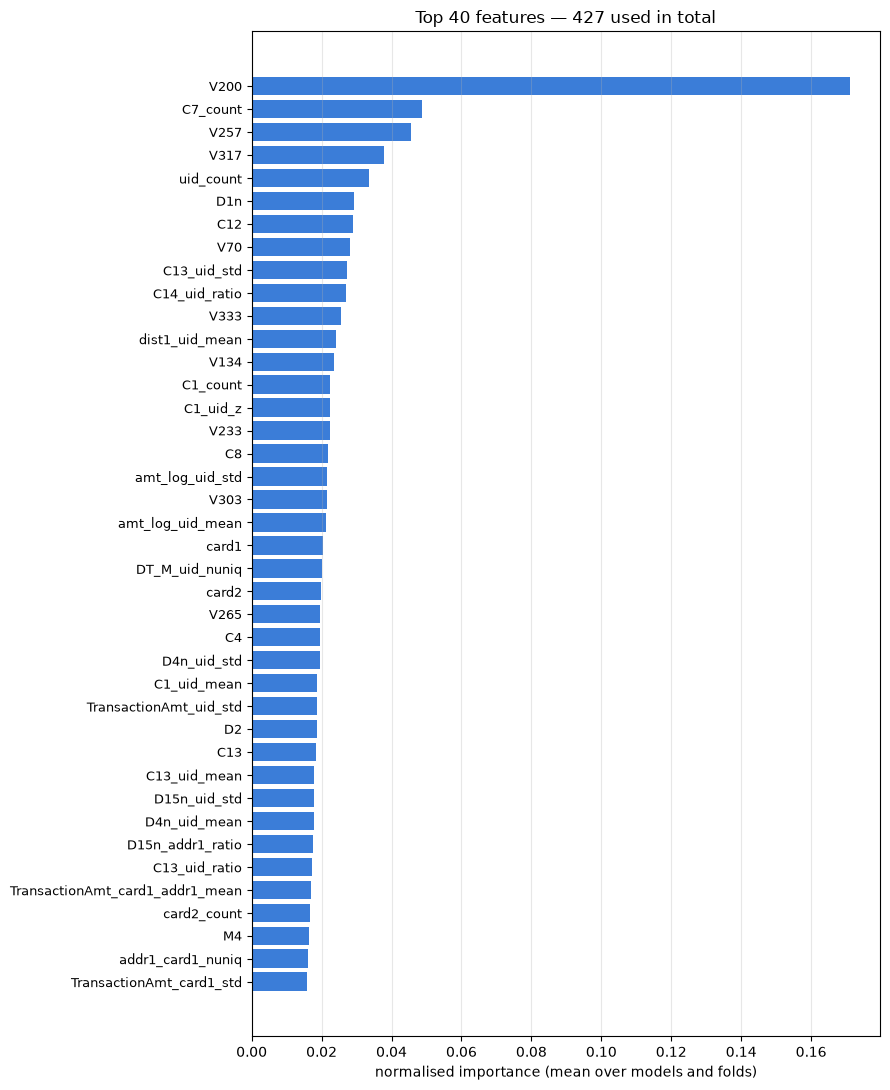

V200                0.171130
C7_count            0.048700
V257                0.045459
V317                0.037979
uid_count           0.033436
D1n                 0.029254
C12                 0.028859
V70                 0.028172
C13_uid_std         0.027148
C14_uid_ratio       0.027014
V333                0.025571
dist1_uid_mean      0.024149
V134                0.023491
C1_count            0.022394
C1_uid_z            0.022359
V233                0.022267
C8                  0.021762
amt_log_uid_std     0.021530
V303                0.021417
amt_log_uid_mean    0.021341
card1               0.020286
DT_M_uid_nuniq      0.020240
card2               0.019688
V265                0.019562
C4                  0.019491


In [30]:
if len(imp_series):
    imp_df = pd.DataFrame({"feature": imp_series.index, "importance": imp_series.to_numpy()})
    imp_df.to_csv(OUT_DIR / "feature_importance.csv", index=False)

    top = imp_series.head(40)[::-1]
    fig, ax = plt.subplots(figsize=(9, 11))
    ax.barh(range(len(top)), top.to_numpy(), color="#3b7dd8")
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=9)
    ax.set_xlabel("normalised importance (mean over models and folds)")
    ax.set_title(f"Top 40 features — {len(FEATURES)} used in total")
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "feature_importance.png", dpi=110)
    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close(fig)
    print(imp_series.head(25).to_string())

## 8. Submission and artifacts

`submission.csv` is the final **cost-optimized cascade** submission. The notebook also saves OOF predictions, Stage-1 threshold diagnostics, Stage-2 blend search, model comparison and final metrics.


## 9. Notes

- **Architecture:** LightGBM screens every transaction; only Stage-1-passed rows are sent to XGBoost and CatBoost.
- **Cost metric:** `stage2_rate` is the fraction of transactions that require the expensive Stage-2 models.
- **Metric guardrail:** the Stage-1 threshold is chosen only from thresholds that retain at least 98% Stage-1 fraud recall **and** do not reduce OOF ROC-AUC or PR-AUC versus the Stage-2 XGB+CatBoost reference. If no selective threshold satisfies both, threshold 0.0 falls back to Stage 2, preventing an OOF metric drop.
- **Test metrics:** the Kaggle test set has no `isFraud`, so Precision/Recall/F1 are not available for test. Use OOF metrics for model evaluation and the test submission for ranking.
- **Unseen-test caveat:** no notebook can mathematically guarantee the same leaderboard score on unseen data. The guardrail is based on labelled OOF evidence and preserves the requested metrics during model selection.
